# Lab9 - Initial Batch Selection

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

The topic of this lab session is initial batch selection. We will focus on algorithms that can be used to bootstrap the active learning cycle.

Till now we have been using random sampling to select the initial batch of objects to be labeled. This is a very simple approach but highly nondeterministic. The models obtained after training may vary in performance. In practical applications there is only one chance to properly choose the initial set to be labeled, therefore it is important to select the objects that will lead to a good model. This is why approaches with low performance variance are in high demand.

#### Why initial batch selection matters
In every active learning system there is a chicken-and-egg moment: before the model can ask informed questions ("which sample is most uncertain?"), it has to be trained on something. That "something" is the initial labeled batch, and in real-world deployments you usually only get to pick it once - labeling is expensive, the budget is fixed, and you cannot retroactively swap out the seed set after committing annotators.

Random sampling, which we have used so far, is the natural default but has two weaknesses: (1) for imbalanced datasets it tends to miss minority classes entirely, and (2) it has high variance - two random seeds can produce models whose performance differs by tens of percentage points, which is unacceptable when you only train once. The goal of this lab is to look for selection strategies that are both better on average and more stable across runs than random.

The intuition behind clustering-based seed selection is simple: if we can identify ~L groups of "similar" examples in the unlabeled pool, then labeling one representative per group should cover the data manifold far more uniformly than random sampling, give the classifier at least one example of every distinguishable region, and dramatically reduce the variance of downstream model performance. This is the original Hu/Kang argument for cluster-based initialization, which we will reproduce empirically here on a pleasingly nasty case with mixed feature types and ~5 orders of magnitude of class imbalance.

## 0. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, MiniBatchKMeans, BisectingKMeans
from sklearn.metrics import balanced_accuracy_score, pairwise_distances_argmin_min

RNG_SEED = 42 


## 1. Data preparation

During this lab we will be using the KDD99 dataset. See: http://kdd.ics.uci.edu/databases/kddcup99/task.html

KDD'99 is a network intrusion detection dataset derived from the DARPA 1998 IDS Evaluation conducted at MIT Lincoln Lab, used as the benchmark for the KDD Cup 1999 competition. The OpenML version 1 (id 1113) corresponds to the well-known "10% subset": 494,020 records, 41 features + 1 target, 23 classes. Each row summarizes a single network connection; the target is normal. or one of 22 attack types (smurf., neptune., back., portsweep., phf., …). Two properties will matter throughout this lab: mixed feature types (most columns are numeric, but protocol_type (3 values), service (~70 values), and flag (~11 values) are strings) and extreme class imbalance. The first call to fetch_openml will take a minute or two - be patient.

In [2]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('KDDCup99', return_X_y=False, version=1)
X = bunch.data
y = bunch.target

X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


### Get familiar with the dataset

In [3]:
bunch.url

'https://www.openml.org/d/1113'

In [4]:
bunch.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   duration                     494020 non-null  int64   
 1   protocol_type                494020 non-null  category
 2   service                      494020 non-null  category
 3   flag                         494020 non-null  category
 4   src_bytes                    494020 non-null  int64   
 5   dst_bytes                    494020 non-null  int64   
 6   land                         494020 non-null  category
 7   wrong_fragment               494020 non-null  int64   
 8   urgent                       494020 non-null  int64   
 9   hot                          494020 non-null  int64   
 10  num_failed_logins            494020 non-null  int64   
 11  logged_in                    494020 non-null  category
 12  lnum_compromised             494020 non-null

### Target distribution

Investigate the distribution oif the target variable - use histogram to present the distribution. Try to use different scales, linear and logarithmic scales for the y-axis. Is the distribution balanced?

Plot both linear and log scales side by side and compare. Also: np.unique returns classes sorted alphabetically, which makes the bar plot harder to read. Sorting by frequency (try pd.Series(y).value_counts()) is much more informative.

While you're here, ask yourself: how many classes have fewer than 10 samples in total? What does that imply for the next step?

Class "back"             - 2203 objects
Class "buffer_overflow"  - 30 objects
Class "ftp_write"        - 8 objects
Class "guess_passwd"     - 53 objects
Class "imap"             - 12 objects
Class "ipsweep"          - 1247 objects
Class "land"             - 21 objects
Class "loadmodule"       - 9 objects
Class "multihop"         - 7 objects
Class "neptune"          - 107201 objects
Class "nmap"             - 231 objects
Class "normal"           - 97277 objects
Class "perl"             - 3 objects
Class "phf"              - 4 objects
Class "pod"              - 264 objects
Class "portsweep"        - 1040 objects
Class "rootkit"          - 10 objects
Class "satan"            - 1589 objects
Class "smurf"            - 280790 objects
Class "spy"              - 2 objects
Class "teardrop"         - 979 objects
Class "warezclient"      - 1020 objects
Class "warezmaster"      - 20 objects


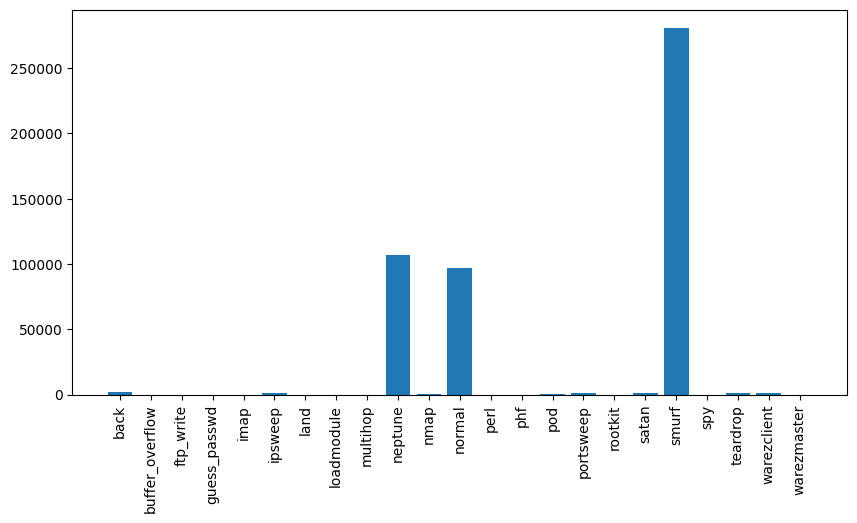

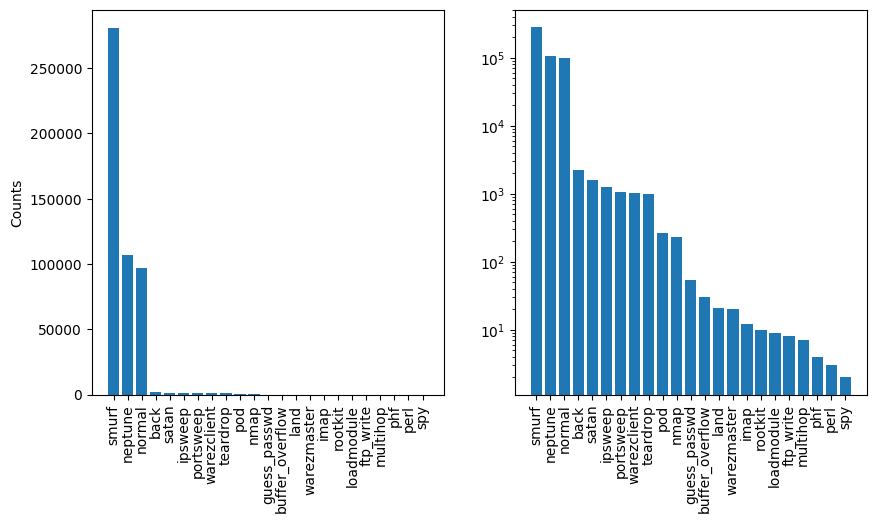

In [5]:
# write your code here

# TODO:
#  1. Count class frequencies (hint: pd.Series(y).value_counts()).
#  2. Plot two histograms side-by-side: linear y-scale and log y-scale.
#  3. Sort bars by frequency, not alphabetically - otherwise the plot is unreadable.

unique, counts = np.unique(y, return_counts=True)
for dec, count in zip(unique, counts):
    print(f'Class "{dec}"'.ljust(25), end = "")
    print(f'- {count} objects')


fig, ax = plt.subplots(figsize=(10, 5))
ax.tick_params(axis='x', rotation=90)
ax.bar(unique, counts)
# ax.set_yscale('log')
plt.show()


labels = pd.Series(y).value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)
ax[0].bar(labels.index, labels.values)
ax[1].bar(labels.index, labels.values)
ax[1].set_yscale('log')
ax[0].set_ylabel('Counts')
plt.show()

### Prepare pool and eval data

Split the dataset into pool and eval subsets (use 60-40 ratio). Use stratified sampling to ensure that the target distribution is preserved in both subsets.

Note: stratified sampling raises a warning if any class has just one sample - and KDD'99 has classes with 2, 3, or 4 total samples, which is technically splittable but practically pointless: a class with 3 samples becomes 2 in train, 1 in eval, and your classifier sees a single example. Worse, when we later take a 1% initial batch of the pool, those rare classes have essentially zero chance of being represented.

You have a few options:

* drop classes below some minimum count and document why,
* merge them into a synthetic rare class,
* skip stratification and verify post-hoc that the major classes are split proportionally.

Pick one and justify it in a comment. 

Set a random_state so your results are reproducible.

label
smurf              168474
neptune             64321
normal              58366
back                 1322
satan                 953
ipsweep               748
portsweep             624
warezclient           612
teardrop              587
pod                   158
nmap                  139
guess_passwd           32
buffer_overflow        18
land                   13
warezmaster            12
imap                    7
rootkit                 6
perl                    0
loadmodule              0
ftp_write               0
phf                     0
multihop                0
spy                     0
Name: count, dtype: int64
label
smurf              112316
neptune             42880
normal              38911
back                  881
satan                 636
ipsweep               499
portsweep             416
warezclient           408
teardrop              392
pod                   106
nmap                   92
guess_passwd           21
buffer_overflow        12
land                    8


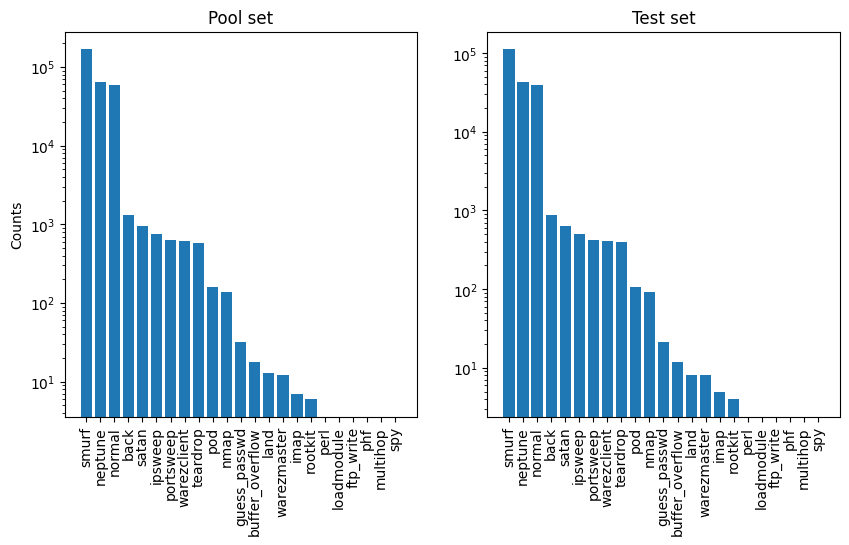

In [6]:
# write your code here

# TODO:
#  - Decide what to do with ultra-rare classes (those with <10 samples).
#    A 60/40 stratified split + 1% sample of the pool simply cannot represent them.
#    Document your decision in a comment.
#  - Perform a stratified 60/40 split with a fixed random_state.
#  - Sanity-check that y_pool and y_eval cover the major classes in similar proportions.

labels = pd.Series(y)

# Zostawiamy tylko klasy z >= 10 wystąpieniami
valid_classes = labels.value_counts()[lambda s: s >= 10].index
# Tworzymy maskę
mask = labels.isin(valid_classes)

#Filtrowanie X i y
X_filtered = X[mask].reset_index(drop=True)
y_filtered = labels[mask].reset_index(drop=True)


X_pool, X_test, y_pool, y_test = train_test_split(X_filtered, y_filtered, test_size=0.4, stratify=y_filtered, random_state=42)

y_pool_counts = pd.Series(y_pool).value_counts()
y_test_counts = pd.Series(y_test).value_counts()

print(y_pool_counts)
print(y_test_counts)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)
ax[0].bar(y_pool_counts.index, y_pool_counts.values)
ax[1].bar(y_test_counts.index, y_test_counts.values)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_title('Pool set')
ax[1].set_title('Test set')
ax[0].set_ylabel('Counts')
plt.show()

W moim skrypcie usunąłem ze zbioru klasy, w których występuje mniej niż 10 wystąpień elementów danej klasy. Pozwala to uniknąć przypadkowości w tym, czy następnie dana klasa w ogóle będzie występować w początkowych batchach. W pewien sposób automatycznie ogranicza to możliwości modelu, jednak w zamian zapewnia większą powtarzalność i stabilność wyników.

## 2. Preprocess the data

We are going to use decision trees as classifiers and the k-means algorithm to select the initial batch of objects. Preprocess the data so that these algorithms can be used.

If you are going to use any methods/algorithms that need to be **"fit"** to the data, use only the pool data for that purpose, but remember to apply the same transformation to the eval data. This will help you to avoid any data leakage issues.

Note:
* Decision trees are scale-invariant, k-means is not. So your preprocessing has to make k-means happy, and the tree will accept whatever you give it.
* Encoding. For features with large number of distinct values, OneHot-encoding MIGHT noticeably slow down k-means. Ordinal encoding is faster and works fine here in practice - though it's technically an approximation for distance-based methods. Document your choice.
* Scaling. Without scaling, the numerical columns with large ranges (e.g., byte counts) will completely dominate the Euclidean distances k-means uses, and your clusters will essentially be 1-dimensional.
* Data leakage. Fit your encoder/scaler on the pool only, then apply .transform to both pool and eval. Do not fit on X (the full dataset) — that leaks eval information into the preprocessing.

A ColumnTransformer is a clean way to handle preprocessing in one object.

In [7]:
# write your code here

# TODO:
#  - Identify which columns are categorical and which are numerical.
#  - Build a ColumnTransformer that handles both. Justify your encoding choice in a comment.
#  - Fit ONLY on the pool, then transform both pool and eval.
#  - At the end you should have X_pool_t and X_eval_t as numeric arrays/matrices.

# Wybór kolumn kategorycznych i numerycznych
cat_cols = ["protocol_type", "service", "flag", "land", "logged_in", "is_host_login", "is_guest_login"]
num_cols = [c for c in X.columns if c not in cat_cols]

#print(X.dtypes)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

#Fitowanie na pool
preprocess.fit(X_pool)

#Transformacje na pool i test
X_pool_t = preprocess.transform(X_pool)
X_eval_t = preprocess.transform(X_test)



## 3. Preliminary experiments

In the preliminary experiments, we will not use any active learning. We will train the model on the initial batch of objects and evaluate it on the evaluation set.

In all experiments, use an initial batch of size 1% of the pool data (`L = 0.01 * len(X_pool)`). We will compare the performance of the following approaches:

- random sampling (our baseline)
- k-means (random sampling from the clusters)
- k-means (use objects that are closest to the cluster centers) 
- *an additional clustering algorithm of your choice

In all experiments, use a decision tree as the model and BAC (balanced accuracy) as the evaluation metric. 

#### Note
Three things you'll run into:
1. Silently dropped classes. With L ≈ 1% of the pool and 23 classes, your initial batch may miss some classes entirely. A decision tree only predicts classes it has seen during training - so for any missing class, every eval sample of that class is misclassified and that class's recall drops to 0. Since BAC is the mean recall across classes, even a few missing classes can hurt it noticeably. This is expected behavior and exactly the phenomenon we're studying - better seeding strategies should miss fewer classes.
2. Trivial classifier collapse. With this much imbalance, a vanilla decision tree on a 1% sample will happily predict the majority class for everything and get a BAC near 1/n_classes. Use DecisionTreeClassifier(class_weight='balanced', ...) to counter this - otherwise none of your methods will look good and you won't see the differences we're trying to measure.
3. Reproducibility. The whole point of this lab is to compare variance across runs. That comparison only makes sense if the non-method sources of randomness (the train/test split, the tree, the preprocessor) are pinned. Use fixed seed for those.



In [8]:
# let's assume that the variable `X_pool` contains the pool of unlabeled data

L = int(0.01 * len(X_pool_t))
print(L)

results = {}

2963


### Prepare baseline

Use random sampling to select the initial batch of objects - 1% of the pool data. Train a decision tree model on the selected objects and assess its performance (BAC) on the evaluation set. Repeat the experiment `BASELINE_ITERATIONS = 100` times and draw a histogram of the results. Compute the mean and standard deviation of the results.

*You might consider using a smaller number of repetitions (e.g., `BASELINE_ITERATIONS = 50`) in order to speed up the process and finish the lab on time.*

Hint: Store every method's BAC scores into the results dict (keyed by method name). At the end of this Section you'll want to overlay all four distributions on a single histogram, and a single dict with consistent shape makes that a one-liner.

In [9]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

BASELINE_ITERATIONS = 100
results['random'] = np.zeros(BASELINE_ITERATIONS)

for i in tqdm(range(BASELINE_ITERATIONS)):
    rng = np.random.default_rng(seed=i)
    idx = rng.choice(len(X_pool_t), size=L, replace=False)

    X_init = X_pool_t[idx]
    y_init = y_pool.iloc[idx]

    clf_random = DecisionTreeClassifier(class_weight='balanced', random_state=42)

    clf_random.fit(X_init, y_init)
    y_pred = clf_random.predict(X_eval_t)

    results['random'][i] = balanced_accuracy_score(y_test, y_pred)



100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


In [10]:
print(f"Mean BAC: {results['random'].mean():.4}")
print(f"BAC std: {results['random'].std():.4}")

Mean BAC: 0.5711
BAC std: 0.0499


### K-means (random sampling from the clusters)

Use k-means algorithm to cluster the pool data into `k = L (i.e., 1% of the pool size)` clusters. Randomly select one object from each cluster and train a decision tree model on the selected objects. Assess its performance (BAC) on the evaluation set. Repeat the experiment `KMEANS_RANDOM_ITERATIONS = 100` times and draw a histogram of the results. Present the results and baseline results on the same plot (e.g., use the plot legend, alpha values and different colors). Compute the mean and standard deviation of the results.

*You might consider using a smaller number of repetitions (e.g., `KMEANS_RANDOM_ITERATIONS = 50`) in order to speed up the process and finish the lab on time.*

Alternatively, if it is still too slow, use MiniBatchKMeans. Quality is slightly noisier than full KMeans but the difference is negligible at this scale and saves you a lot of waiting.

In [11]:
# write your code here

# TODO:
#  - For each of KMEANS_RANDOM_ITERATIONS iterations:
#      fit a clusterer with k = L on X_pool_t (use a different random_state each time);
#      pick ONE random sample from each cluster;
#      call train_and_score, store the BAC.
#  - Save into results['kmeans_random'].
#
# Practical notes:
#  - Plain KMeans at k = L (~thousands) is too slow. Use MiniBatchKMeans.
#  - A cluster could in principle be empty; decide how to handle it
#    (e.g., top up with random samples to reach exactly L).

from sklearn.cluster import MiniBatchKMeans

KMEANS_RANDOM_ITERATIONS = 100
results['kmeans_random'] = np.zeros(KMEANS_RANDOM_ITERATIONS)

for i in tqdm(range(KMEANS_RANDOM_ITERATIONS)):
    
    rng = np.random.default_rng(seed=i)

    kmeans = MiniBatchKMeans(n_clusters=L, random_state=i, batch_size=2048)
    kmeans.fit(X_pool_t)

    labels = kmeans.labels_
    unique_clusters = np.unique(labels)

    selected_indices = []

    # Losowanie po 1 punkcie z każdego klastra
    for c in unique_clusters:
        cluster_indices = np.where(labels == c)[0]

        if len(cluster_indices) == 0:
            # klaster pusty - losowy punkt z całej puli
            chosen = rng.choice(len(X_pool_t), size=1)
        else:
            chosen = rng.choice(cluster_indices, size=1)

        selected_indices.append(chosen[0])

    selected_indices = np.array(selected_indices)

    X_init = X_pool_t[selected_indices]
    y_init = y_pool.iloc[selected_indices]

    clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    clf.fit(X_init, y_init)

    y_pred = clf.predict(X_eval_t)
    results['kmeans_random'][i] = balanced_accuracy_score(y_test, y_pred)


100%|██████████| 100/100 [06:41<00:00,  4.02s/it]


In [12]:
print(f"Mean BAC: {results['kmeans_random'].mean():.4}")
print(f"BAC std: {results['kmeans_random'].std():.4}")

Mean BAC: 0.7014
BAC std: 0.05287


### K-means (use objects that are closest to the cluster centers)

Instead of randomly selecting one object from each cluster, use the centroids of each cluster to find the objects that are closest to the cluster centers and form the initial batch. Train a decision tree model on the selected objects and assess its performance (BAC) on the evaluation set. Repeat the experiment `KMEANS_CENTERS_ITERATIONS = 100` times and draw a histogram of the results - try to present all the results on the same plot. Compute the mean and standard deviation of the results.

*You might consider using a smaller number of repetitions (e.g., `KMEANS_CENTERS_ITERATIONS = 50`) in order to speed up the process and finish the lab on time.*

Question: Why are we repeating this 100 times if the procedure sounds deterministic?
Stop and think about this before you start coding. Once a clustering is fixed, picking the closest point to each centroid is deterministic. So where does the variance come from?

Hints:
* Use a different random_state for the clusterer in each iteration. If you accidentally fix it, you'll get 100 identical scores and wonder what went wrong.
* sklearn.metrics.pairwise_distances_argmin_min does the "find closest pool point to each centroid" step in one call.

In [13]:
# write your code here

# TODO:
#  - For each of KMEANS_CENTERS_ITERATIONS iterations:
#      fit MiniBatchKMeans (different random_state each time);
#      find the pool sample closest to each centroid
#      (hint: pairwise_distances_argmin_min);
#      call train_and_score, store the BAC.
#  - Save into results['kmeans_centroid'].

# TODO:
#  - Single overlaid histogram of BAC distributions for all methods in `results`.
#  - Use alpha < 1 so distributions are visible through each other.
#  - Legend should include mean and std for each method.

from sklearn.metrics.pairwise import pairwise_distances_argmin_min

KMEANS_CENTERS_ITERATIONS = 100
results['kmeans_centroid'] = np.zeros(KMEANS_CENTERS_ITERATIONS)

for i in tqdm(range(KMEANS_CENTERS_ITERATIONS)):
    
    rng = np.random.default_rng(seed=i)

    kmeans = MiniBatchKMeans(n_clusters=L, random_state=i, batch_size=2048)
    kmeans.fit(X_pool_t)

    selected_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_pool_t)

    X_init = X_pool_t[selected_indices]
    y_init = y_pool.iloc[selected_indices]

    clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    clf.fit(X_init, y_init)

    y_pred = clf.predict(X_eval_t)
    results['kmeans_centroid'][i] = balanced_accuracy_score(y_test, y_pred)


100%|██████████| 100/100 [07:12<00:00,  4.33s/it]


In [14]:
print(f"Mean BAC: {results['kmeans_centroid'].mean():.4}")
print(f"BAC std: {results['kmeans_centroid'].std():.4}")

Mean BAC: 0.6391
BAC std: 0.0452


### Histogram of the results

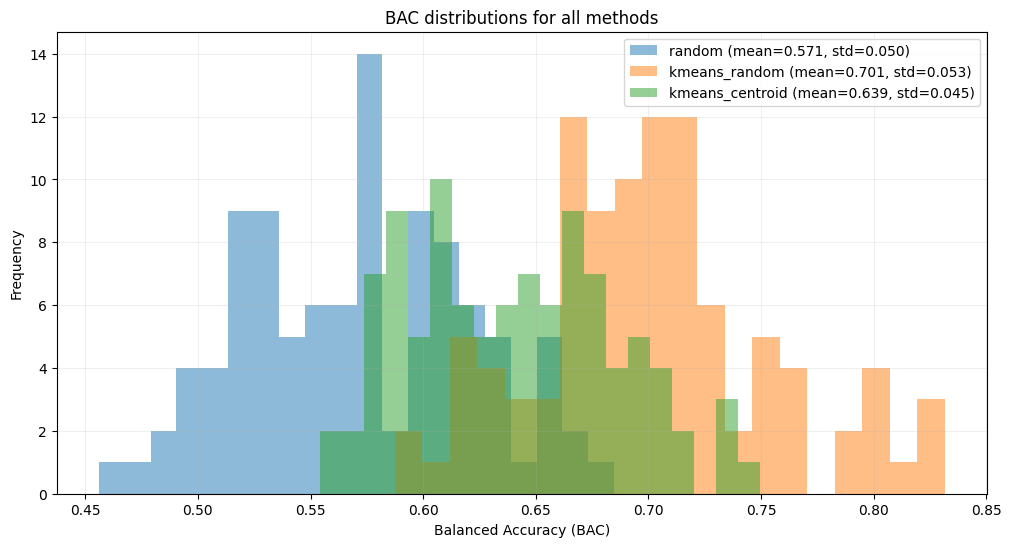

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

for method, scores in results.items():
    mean = np.mean(scores)
    std = np.std(scores)

    plt.hist(
        scores,
        bins=20,
        alpha=0.5,
        label=f"{method} (mean={mean:.3f}, std={std:.3f})"
    )

plt.xlabel("Balanced Accuracy (BAC)")
plt.ylabel("Frequency")
plt.title("BAC distributions for all methods")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### *Use another clustering algorithm

Use an additional clustering algorithm of your choice with random and centroid approaches. Compare the results with the previous ones. 

Suggestion. Anything that takes n_clusters as a parameter will work as a drop-in replacement: BisectingKMeans (often higher quality at large k than vanilla KMeans), BIRCH (memory-efficient at large k), or agglomerative clustering on a subsample (the full pool will OOM with hierarchical methods).
Density-based methods that don't take k as a parameter on KDD'99 they might tend to dump almost everything into one giant cluster plus a long tail of noise. Don't waste an hour debugging them.

In [16]:
# write your code here


# TODO:
#  - Pick another clustering algorithm (suggestions: BisectingKMeans, BIRCH).
#    Avoid methods like DBSCAN/HDBSCAN
#  - Repeat both the random-from-cluster and closest-to-centroid experiments.
#  - Add to results and re-plot the combined histogram.

from sklearn.cluster import Birch


BIRCH_RANDOM_ITERATIONS = 100
results['birch_random'] = np.zeros(BIRCH_RANDOM_ITERATIONS)

for i in tqdm(range(BIRCH_RANDOM_ITERATIONS)):
    
    rng = np.random.default_rng(seed=i)

    birch = Birch(n_clusters=L, threshold=0.5).fit(X_pool_t)

    labels = birch.labels_
    unique_clusters = np.unique(labels)

    selected_indices = []

    # Losowanie po 1 punkcie z każdego klastra
    for c in unique_clusters:
        cluster_indices = np.where(labels == c)[0]

        if len(cluster_indices) == 0:
            # klaster pusty - losowy punkt z całej puli
            chosen = rng.choice(len(X_pool_t), size=1)
        else:
            chosen = rng.choice(cluster_indices, size=1)

        selected_indices.append(chosen[0])

    selected_indices = np.array(selected_indices)

    X_init = X_pool_t[selected_indices]
    y_init = y_pool.iloc[selected_indices]

    clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    clf.fit(X_init, y_init)

    y_pred = clf.predict(X_eval_t)
    results['birch_random'][i] = balanced_accuracy_score(y_test, y_pred)


100%|██████████| 100/100 [14:34<00:00,  8.75s/it]


In [17]:
print(f"Mean BAC: {results['birch_random'].mean():.4}")
print(f"BAC std: {results['birch_random'].std():.4}")

Mean BAC: 0.8756
BAC std: 0.02802


In [18]:
BIRCH_CENTERS_ITERATIONS = 100
results['birch_centroid'] = np.zeros(BIRCH_CENTERS_ITERATIONS)

for i in tqdm(range(BIRCH_CENTERS_ITERATIONS)):
    
    rng = np.random.default_rng(seed=i)

    birch = Birch(n_clusters=L, threshold=0.5).fit(X_pool_t)

    labels = birch.labels_
    unique_clusters = np.unique(labels)

    selected_indices = []

    for c in unique_clusters:
        cluster_indices = np.where(labels == c)[0]

        if len(cluster_indices) == 0:
            # awaryjnie – pusty klaster, bierzemy losowy punkt z całej puli
            chosen = rng.choice(len(X_pool_t), size=1)
            selected_indices.append(chosen[0])
            continue

        # centroid klastra liczony z punktów
        cluster_points = X_pool_t[cluster_indices]
        center = cluster_points.mean(axis=0, keepdims=True)

        # indeks punktu w tym klastrze najbliższego centroidowi
        local_idx, _ = pairwise_distances_argmin_min(center, cluster_points)
        selected_indices.append(cluster_indices[local_idx[0]])

    selected_indices = np.array(selected_indices)

    X_init = X_pool_t[selected_indices]
    y_init = y_pool.iloc[selected_indices]

    clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    clf.fit(X_init, y_init)

    y_pred = clf.predict(X_eval_t)
    results['birch_centroid'][i] = balanced_accuracy_score(y_test, y_pred)

100%|██████████| 100/100 [26:21<00:00, 15.82s/it]


In [19]:
print(f"Mean BAC: {results['birch_centroid'].mean():.4}")
print(f"BAC std: {results['birch_centroid'].std():.4}")

Mean BAC: 0.9058
BAC std: 2.22e-16


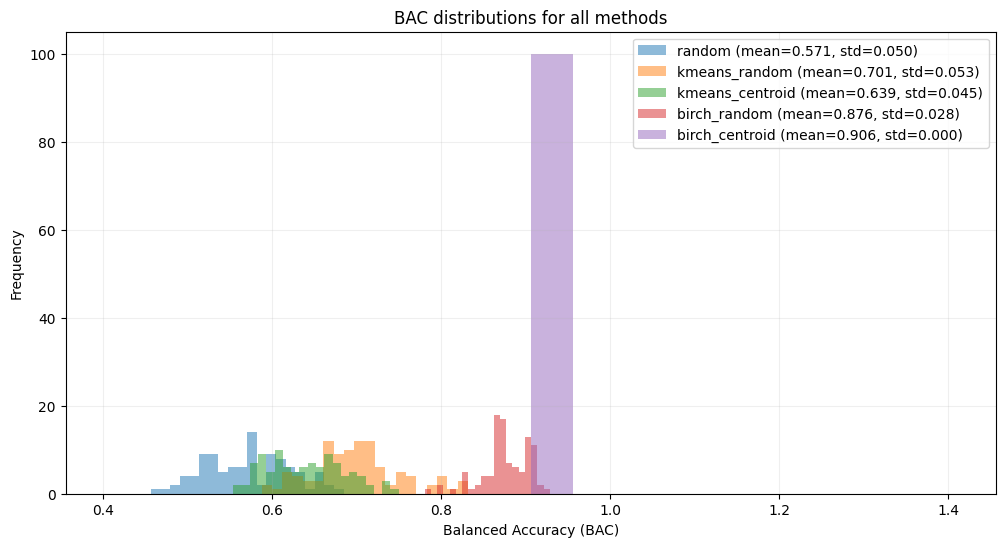

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

for method, scores in results.items():
    mean = np.mean(scores)
    std = np.std(scores)

    plt.hist(scores, bins=20, alpha=0.5, label=f"{method} (mean={mean:.3f}, std={std:.3f})")

plt.xlabel("Balanced Accuracy (BAC)")
plt.ylabel("Frequency")
plt.title("BAC distributions for all methods")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 4. Active learning experiments

Evaluate the initial batch selection approaches in the active learning setting. Use your active learning framework and perform experiments with entropy informativeness function (or any other of your choice) and the stop criterion based on the labeled set size equal to `L + 0.03 * len(X_pool)`. This means that we stop when there are 4% of the pool data labeled - 1% from the initial batch and 3% from the active learning loop.

Are the results similar to the ones obtained in the preliminary experiments? Do you observe any differences?

* Remember to retrain in batches. Use a small batch per query (50-100 samples) to keep the lab finishable. State your choice in a comment.
* Entropy edge case. Decision trees can output exact zero probabilities for unseen-in-training classes, and log(0) = -inf. Clip probabilities to a small epsilon (e.g. 1e-12) before computing entropy, otherwise NaNs will propagate and your argmax becomes meaningless.
* Plot learning curves (BAC vs. number of labeled samples) for each seeding method, with shaded ±1σ bands across runs. The interesting question isn't just "which method ends highest". It is also whether the gap between methods at t=0 (initial batch only) shrinks, persists, or inverts as you add more labels. Sometimes the cluster-based methods stay ahead the whole way. sometimes random catches up after a few hundred queries.

In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import Birch
from sklearn.metrics.pairwise import pairwise_distances_argmin_min

def init_random(X_t, y, L, seed=42):
    rng = np.random.default_rng(seed=seed)
    # losujemy L indeksów z CAŁEGO X_t
    idx = rng.choice(len(X_t), size=L, replace=False)
    # initial batch
    X_init = X_t[idx]
    y_init = y.iloc[idx]
    # pool = reszta próbek
    mask = np.ones(len(X_t), dtype=bool)
    mask[idx] = False

    X_pool = X_t[mask]
    y_pool = y.iloc[mask]
    return X_init, y_init, X_pool, y_pool


def init_kmeans_random(X_t, y, L, seed=42):
    """
    Wybiera L próbek: po jednej losowej z każdego z L klastrów k-means.
    Zwraca:
        X_init, y_init  – początkowy batch
        X_pool, y_pool  – reszta próbek
    """

    rng = np.random.default_rng(seed)
    # K-means z L klastrami
    kmeans = MiniBatchKMeans(n_clusters=L, random_state=seed, batch_size=2048).fit(X_t)

    labels = kmeans.labels_
    unique_clusters = np.unique(labels)
    selected_indices = []

    # Losowanie po 1 punkcie z każdego klastra
    for c in unique_clusters:
        cluster_idx = np.where(labels == c)[0]

        if len(cluster_idx) == 0:
            # klaster pusty - fallback: losowy punkt z całej puli
            chosen = rng.choice(len(X_t), size=1)
        else:
            chosen = rng.choice(cluster_idx, size=1)

        selected_indices.append(chosen[0])

    selected_indices = np.array(selected_indices)

    # Initial batch
    X_init = X_t[selected_indices]
    y_init = y.iloc[selected_indices]
    # Pool = reszta próbek
    mask = np.ones(len(X_t), dtype=bool)
    mask[selected_indices] = False

    X_pool = X_t[mask]
    y_pool = y.iloc[mask]
    return X_init, y_init, X_pool, y_pool


def init_kmeans_centroid(X_t, y, L, seed=42):
    """
    Wybiera L próbek: po jednej najbliższej centroidowi każdego z L klastrów k-means.
    Zwraca:
        X_init, y_init  – początkowy batch
        X_pool, y_pool  – reszta próbek
    """

    # K-means z L klastrami
    kmeans = MiniBatchKMeans(
        n_clusters=L,
        random_state=seed,
        batch_size=2048
    )
    kmeans.fit(X_t)

    # 2. Najbliższe punkty do centroidów
    #    Zwraca indeksy w X_t
    selected_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_t)

    # 3. Initial batch
    X_init = X_t[selected_indices]
    y_init = y.iloc[selected_indices]

    # 4. Pool = reszta próbek
    mask = np.ones(len(X_t), dtype=bool)
    mask[selected_indices] = False

    X_pool = X_t[mask]
    y_pool = y.iloc[mask]

    return X_init, y_init, X_pool, y_pool


def init_birch_random(X_t, y, L, seed=42):
    """
    Wybiera L próbek: po jednej losowej z każdego z L klastrów Birch.
    Zwraca:
        X_init, y_init  – początkowy batch
        X_pool, y_pool  – reszta próbek
    """

    rng = np.random.default_rng(seed)

    # Birch clustering
    birch = Birch(n_clusters=L, threshold=0.5)
    birch.fit(X_t)

    labels = birch.labels_
    unique_clusters = np.unique(labels)

    selected_indices = []

    # Losowanie po 1 punkcie z każdego klastra
    for c in unique_clusters:
        cluster_idx = np.where(labels == c)[0]

        if len(cluster_idx) == 0:
            # klaster pusty -> losowy punkt z całej puli
            chosen = rng.choice(len(X_t), size=1)
        else:
            chosen = rng.choice(cluster_idx, size=1)

        selected_indices.append(chosen[0])

    selected_indices = np.array(selected_indices)

    # Initial batch
    X_init = X_t[selected_indices]
    y_init = y.iloc[selected_indices]

    # Pool = reszta próbek
    mask = np.ones(len(X_t), dtype=bool)
    mask[selected_indices] = False

    X_pool = X_t[mask]
    y_pool = y.iloc[mask]
    return X_init, y_init, X_pool, y_pool



def init_birch_centroid(X_t, y, L, seed=42):
    """
    Wybiera L próbek: po jednej najbliższej centroidowi każdego z L klastrów Birch.
    Zwraca:
        X_init, y_init  – początkowy batch
        X_pool, y_pool  – reszta próbek
    """

    rng = np.random.default_rng(seed)

    # Birch clustering
    birch = Birch(n_clusters=L, threshold=0.5)
    birch.fit(X_t)

    labels = birch.labels_
    unique_clusters = np.unique(labels)
    selected_indices = []

    # Dla każdego klastra wybierz punkt najbliższy centroidowi
    for c in unique_clusters:
        cluster_idx = np.where(labels == c)[0]

        if len(cluster_idx) == 0:
            # fallback: losowy punkt z całej puli
            chosen = rng.choice(len(X_t), size=1)
            selected_indices.append(chosen[0])
            continue

        cluster_points = X_t[cluster_idx]

        # centroid klastra
        center = cluster_points.mean(axis=0, keepdims=True)

        # punkt najbliższy centroidowi
        local_idx, _ = pairwise_distances_argmin_min(center, cluster_points)
        selected_indices.append(cluster_idx[local_idx[0]])

    selected_indices = np.array(selected_indices)

    # 3. Initial batch
    X_init = X_t[selected_indices]
    y_init = y.iloc[selected_indices]

    # 4. Pool = reszta próbek
    mask = np.ones(len(X_t), dtype=bool)
    mask[selected_indices] = False

    X_pool = X_t[mask]
    y_pool = y.iloc[mask]

    return X_init, y_init, X_pool, y_pool


In [22]:
# write your code here

# TODO:
#  - Reuse your AL framework from previous labs (or write a small loop here).
#  - Stop criterion: |labeled set| >= L + 0.03 * len(X_pool_t).
#  - Acquisition: entropy of predict_proba (or another informativeness function).
#    Watch out: clip probabilities away from 0 before log to avoid -inf.
#  - For each seeding method (random, kmeans_random, kmeans_centroid, your-choice):
#      run the AL loop a few times with different seeds,
#      record the learning curve (n_labeled, BAC) at each step.
#  - Plot all learning curves on one chart, with shaded ±1σ bands.

def entropy_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.clip(predictions_probabilities, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

def select_top_k(informativeness, k=1):
    idx = np.argsort(-informativeness)[:k]
    return idx

def active_learning_experiment(
    X_init,
    y_init,
    X_pool,
    y_pool,
    X_eval,
    y_eval,
    classifier=DecisionTreeClassifier,
    info_func=entropy_informativeness,
    selection_strategy=select_top_k,
    batch_size=64,
    metric=balanced_accuracy_score,
    max_labels=int(L*0.04),
    random_state=42,
    **kwargs
):

    # start
    X_labeled = np.copy(X_init)
    y_labeled = np.copy(y_init)

    X_unlabeled = np.copy(X_pool)
    y_unlabeled = np.copy(y_pool)

    # classifier
    clf = classifier(class_weight="balanced", random_state=random_state, **kwargs)

    # learning curve
    learning_curve = []

    while len(X_labeled) < max_labels:

        # 1. retraining
        clf.fit(X_labeled, y_labeled)

        # 2. evaluation
        y_pred = clf.predict(X_eval)
        bac = metric(y_eval, y_pred)
        learning_curve.append(bac)

        # 3. koniec jeśli brak próbek
        if len(X_unlabeled) == 0:
            break

        # 4. informativeness
        proba = clf.predict_proba(X_unlabeled)
        info_values = info_func(proba)

        # 5. wybór batcha
        idx = selection_strategy(info_values, k=min(batch_size, len(X_unlabeled)))

        # 6. aktualizacja zbiorów
        X_labeled = np.vstack([X_labeled, X_unlabeled[idx]])
        y_labeled = np.concatenate([y_labeled, y_unlabeled[idx]])

        mask = np.ones(len(X_unlabeled), dtype=bool)
        mask[idx] = False
        X_unlabeled = X_unlabeled[mask]
        y_unlabeled = y_unlabeled[mask]

    return np.array(learning_curve)


In [23]:
# Założenie: masz już
# X_pool_t, y_pool, X_eval_t, y_test
# oraz funkcje:
# init_random, init_kmeans_random, init_kmeans_centroid,
# init_birch_random, init_birch_centroid
# + active_learning_experiment z Twojego kodu.

SEEDING_METHODS = {
    "random": init_random,
    "kmeans_random": init_kmeans_random,
    "kmeans_centroid": init_kmeans_centroid,
    "birch_random": init_birch_random,
    "birch_centroid": init_birch_centroid,
}

n_runs = 10
batch_size = 64

N = len(X_pool_t)
L = int(0.01 * N)
max_labels = L + int(0.03 * N)

all_curves = {}

for method_name, init_fn in SEEDING_METHODS.items():
    curves = []

    for seed in tqdm(range(n_runs)):
        # seeding
        X_init_AL, y_init_AL, X_pool_AL, y_pool_AL = init_fn(X_pool_t, y_pool, L, seed=seed)

        # AL loop
        curve = active_learning_experiment(
            X_init=X_init_AL,
            y_init=y_init_AL,
            X_pool=X_pool_AL,
            y_pool=y_pool_AL,
            X_eval=X_eval_t,
            y_eval=y_test,
            classifier=DecisionTreeClassifier,
            info_func=entropy_informativeness,
            selection_strategy=select_top_k,
            batch_size=batch_size,
            metric=balanced_accuracy_score,
            max_labels=max_labels,
            random_state=seed,
        )

        curves.append(curve)
        
    # po zebraniu wszystkich curve w curves:
    min_len = min(len(c) for c in curves)
    curves = np.array([c[:min_len] for c in curves])

    all_curves[method_name] = curves



100%|██████████| 10/10 [11:41<00:00, 70.14s/it]


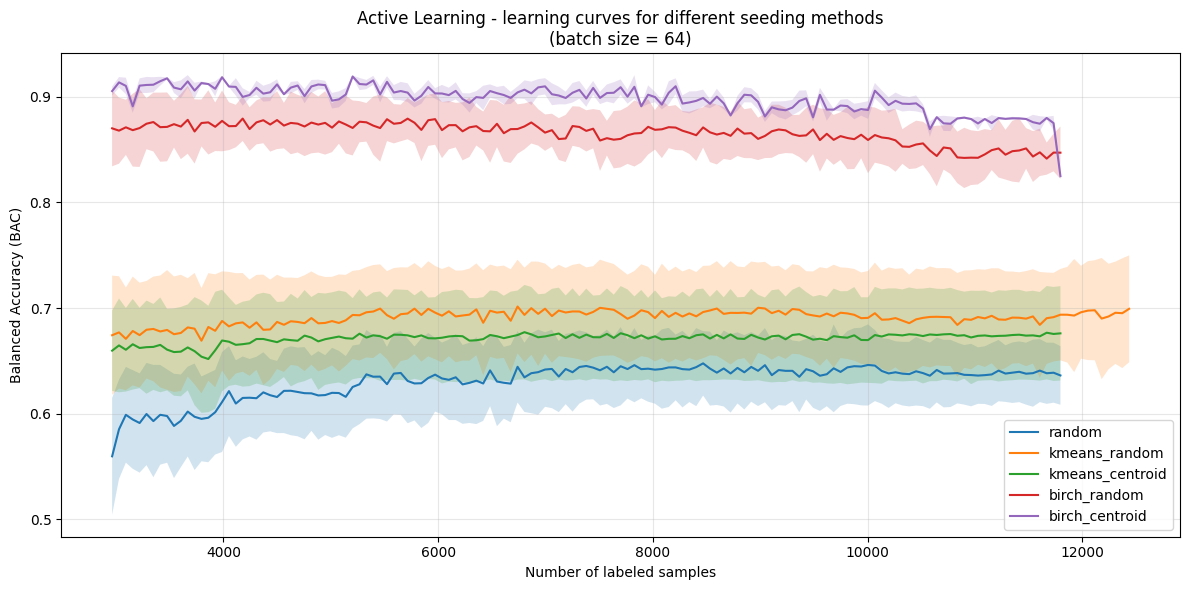

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for method_name, curves in all_curves.items():
    # curves: shape (n_runs, T)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)

    # liczba etykiet w kolejnych krokach:
    # start: L, potem co iterację dokładamy batch_size
    steps = np.arange(len(mean_curve))
    n_labeled = L + steps * batch_size

    plt.plot(n_labeled, mean_curve, label=method_name)
    plt.fill_between(
        n_labeled,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.2,
    )

plt.xlabel("Number of labeled samples")
plt.ylabel("Balanced Accuracy (BAC)")
plt.title("Active Learning - learning curves for different seeding methods\n(batch size = 64)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### What you should walk away with

The performance of an active learning pipeline is bottlenecked by the seed batch. Good acquisition functions cannot rescue a pathological initialization.

Cluster-based seeding (k-means + closest-to-centroid in particular) typically wins on both axes that matter: higher mean BAC and substantially lower variance across runs. Random sampling can occasionally tie on the mean but almost never on the variance.

The choice between random-from-cluster and centroid-closest is a representativeness vs. diversity trade-off. Centroid-closest picks the most "typical" point of each cluster - robust but conservative; random-from-cluster preserves intra-cluster diversity at the cost of stability.

None of this is free: clustering with k ≈ 1% of pool size is computationally non-trivial. MiniBatchKMeans and BIRCH are your friends.

After the active learning loop runs long enough, all reasonable seeding strategies tend to converge - but the path to convergence, and the worst-case run, is what differs. In production you care about the worst case.